# Pix2Pix Final Project - Training Notebook

## Project Goal

The goal of this project is to solve an image-to-image translation task:

- **Input:** 128x128 sketch image
- **Output:** 128x128 RGB flower image
- **Dataset:** Oxford Flowers 102
- **Framework:** TensorFlow / Keras

The project follows the "Image-to-Image Translation with Conditional Adversarial Networks", 2017. paper idea for translating sketches into realistic images: https://arxiv.org/pdf/1611.07004

We implement and compare two required approaches:

1. **Naive baseline:** an encoder-decoder model trained with reconstruction loss only.
2. **Pix2Pix:** a conditional GAN using a U-Net generator and PatchGAN discriminator.

---

## Assignment Requirements Covered in This Notebook

## What this notebook includes:

- Data loading and preprocessing
- Sketch to image pairing
- Naive baseline training
- Pix2Pix training
- PatchGAN comparison
- Training visualization (images + loss graphs)
- Saving best models

---

##Important Note:
This notebook contains the main training pipeline required for the project.

It includes:
- Naive baseline training
- Pix2Pix training
- PatchGAN receptive field comparison

**Additional hyperparameter experiments are presented in a separate experiments notebook.**

# Prep Work

## Imports and Setup

In [ ]:
%%capture
!pip install ipython-autotime
%load_ext autotime

In [ ]:
!pip install -q tensorflow-datasets

In [ ]:
import os
import json
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import layers

from pathlib import Path
from IPython.display import display

from google.colab import drive

In [ ]:
drive.mount('/content/drive')

PROJECT_DIR = Path("/content/drive/MyDrive/Pix2Pix_Final_Project/Train_Notebook")
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"

NAIVE_DIR = OUTPUT_DIR / "naive"
PIX2PIX_DIR = OUTPUT_DIR / "pix2pix"
FIGURES_DIR = OUTPUT_DIR / "figures"
METADATA_DIR = OUTPUT_DIR / "metadata"

for folder in [PROJECT_DIR, DATA_DIR, OUTPUT_DIR, NAIVE_DIR, PIX2PIX_DIR, FIGURES_DIR, METADATA_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Data directory:", DATA_DIR)
print("Output directory:", OUTPUT_DIR)

## Reproducibility and Global Parameters

We fix random seeds to make the experiments more reproducible.

We use:

- `IMG_SIZE = 128`, because the assignment requires 128x128 input and output images.
- `BATCH_SIZE = 16`, as a practical balance between GPU memory and stable training.

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = 128
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

## Helper Function for Saving Experiment Metadata

For every experiment, we save a small JSON file that documents:
- experiment name
- model type
- important hyperparameters
- best validation metric
- saved model path

This will help us later compare saved models in a separate comparison notebook.


In [ ]:
def save_experiment_metadata(save_path, metadata_dict):
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)

    with open(save_path, "w") as f:
        json.dump(metadata_dict, f, indent=4)

    print(f"Metadata saved to: {save_path}")

## Dataset

We use the Oxford Flowers 102 dataset (~8189 images).

Each image is converted into a pair:
- Input: sketch
- Target: real RGB image

This creates supervised training data for Pix2Pix.

In [ ]:
train_ds_raw = tfds.load(
    "oxford_flowers102",
    split="train",
    data_dir=str(DATA_DIR),
    shuffle_files=False
)

val_ds_raw = tfds.load(
    "oxford_flowers102",
    split="validation",
    data_dir=str(DATA_DIR),
    shuffle_files=False
)

test_ds_raw = tfds.load(
    "oxford_flowers102",
    split="test",
    data_dir=str(DATA_DIR),
    shuffle_files=False
)

print("Raw datasets loaded successfully.")

## Sketch Generation

We convert each image into a sketch using edge detection.

Each training pair:
(sketch, real image)

The model must reconstruct color and texture from structural information only.

In [ ]:
def create_pencil_sketch_from_bgr(img_bgr):
    # image -> sketch (Canny edges)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray_blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(gray_blur, 50, 150)
    edges = cv2.dilate(edges, np.ones((3, 3), np.uint8), iterations=1)
    sketch_edges = 255 - edges

    # image -> pencil sketch
    gray_f = gray.astype(np.float32)
    inv = 255.0 - gray_f
    inv_blur = cv2.GaussianBlur(inv, (0, 0), 8.0)
    denom = np.maximum(255.0 - inv_blur, 1e-3)
    pencil = np.clip(gray_f * 255.0 / denom, 0, 255).astype(np.uint8)

    return pencil

### Visualizing a Sketch-Target Pair

We visualize a sample pair to verify:
- correct preprocessing
- alignment between sketch and target

In [ ]:
def load_and_prepare_example_from_tfds(example, img_size=128):
    img_rgb = example["image"].numpy()
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    img_bgr = cv2.resize(img_bgr, (img_size, img_size))

    pencil = create_pencil_sketch_from_bgr(img_bgr)
    img_rgb_resized = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    return pencil, img_rgb_resized

example_sample = next(iter(train_ds_raw))
example_sketch, example_rgb = load_and_prepare_example_from_tfds(example_sample, IMG_SIZE)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(example_sketch, cmap="gray")
plt.title("Input Sketch")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(example_rgb)
plt.title("Target Real Image")
plt.axis("off")
plt.show()

## Preprocessing Pipeline

Each example is converted into:
- sketch input
- RGB target

Steps:
1. Resize to 128×128
2. Convert to sketch
3. Normalize to [-1, 1]

Normalization matches the generator output (tanh) and stabilizes training.

In [ ]:
def preprocess_tfds_example(example):
    image = example["image"]

    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.uint8)

    def _make_pair(img_rgb):
        img_rgb = np.array(img_rgb)
        img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

        sketch = create_pencil_sketch_from_bgr(img_bgr)

        sketch = sketch.astype(np.float32) / 127.5 - 1.0
        sketch = np.expand_dims(sketch, axis=-1)

        real_rgb = img_rgb.astype(np.float32) / 127.5 - 1.0
        return sketch, real_rgb

    sketch, real = tf.numpy_function(
        _make_pair,
        [image],
        [tf.float32, tf.float32]
    )

    sketch.set_shape((IMG_SIZE, IMG_SIZE, 1))
    real.set_shape((IMG_SIZE, IMG_SIZE, 3))

    return sketch, real

## Dataset Pipeline

We build tf.data pipelines with:
- shuffling (train only)
- preprocessing
- batching
- prefetching

In [ ]:
def build_dataset(ds_raw, batch_size=16, shuffle=False, shuffle_buffer=1000):
    ds = ds_raw
    if shuffle:
        ds = ds.shuffle(shuffle_buffer, seed=SEED)

    ds = ds.map(preprocess_tfds_example, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds = build_dataset(train_ds_raw, batch_size=BATCH_SIZE, shuffle=True)
val_ds   = build_dataset(val_ds_raw, batch_size=BATCH_SIZE, shuffle=False)
test_ds  = build_dataset(test_ds_raw, batch_size=BATCH_SIZE, shuffle=False)

print(train_ds)
print(val_ds)
print(test_ds)


## Sanity Check

We verify:
- input and target shapes
- value ranges after normalization

In [ ]:
sample_sketch_batch, sample_real_batch = next(iter(train_ds))

print("Sketch batch shape:", sample_sketch_batch.shape)
print("Real batch shape:", sample_real_batch.shape)

print("Sketch range:", tf.reduce_min(sample_sketch_batch).numpy(), "to", tf.reduce_max(sample_sketch_batch).numpy())
print("Real range:", tf.reduce_min(sample_real_batch).numpy(), "to", tf.reduce_max(sample_real_batch).numpy())

### Visualize Batch

We visualize sketch-target pairs to confirm correct data alignment.

In [ ]:
def denormalize(img):
    return (img + 1.0) / 2.0

sample_sketch_batch, sample_real_batch = next(iter(train_ds))

plt.figure(figsize=(12, 8))
for i in range(4):
    plt.subplot(4, 2, 2 * i + 1)
    plt.imshow(denormalize(sample_sketch_batch[i, :, :, 0]), cmap="gray")
    plt.title("Sketch")
    plt.axis("off")

    plt.subplot(4, 2, 2 * i + 2)
    plt.imshow(denormalize(sample_real_batch[i]))
    plt.title("Real Image")
    plt.axis("off")

plt.tight_layout()
plt.show()



---



---





# Method A: Naive Baseline

We first implement a simple encoder-decoder model.

Input: sketch  
Output: RGB image  

This model is trained using reconstruction loss only (no GAN).

Purpose:
To provide a baseline for comparison with Pix2Pix.

## Model Architecture

The model is an encoder-decoder:

- Encoder: reduces spatial resolution and extracts features  
- Bottleneck: compressed representation  
- Decoder: reconstructs the RGB image  

Limitation:
No skip connections -> loss of fine details (blurry outputs)

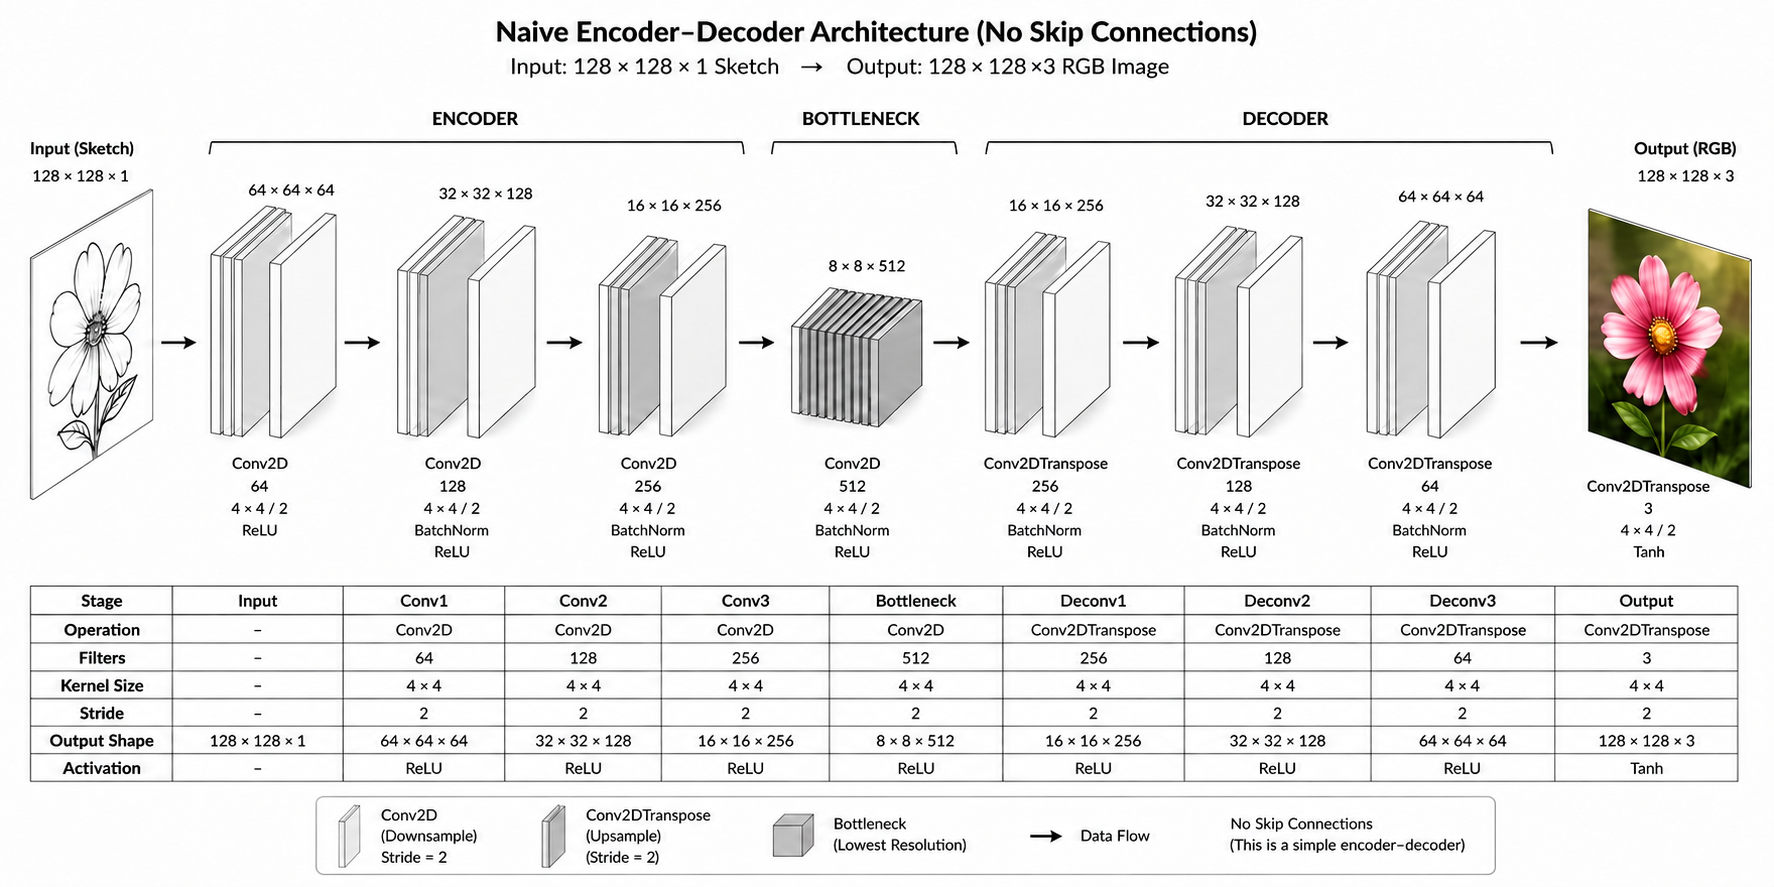

In [ ]:
def build_naive_model(img_size=128):
    inputs = layers.Input(shape=(img_size, img_size, 1), name="input_layer")

    # Encoder: gradually compress spatial information
    x = layers.Conv2D(64, 4, strides=2, padding="same", activation="relu", name="layer_1")(inputs)

    x = layers.Conv2D(128, 4, strides=2, padding="same", name="layer_2" )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(256, 4, strides=2, padding="same", name="layer_3")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Bottleneck: compact latent representation
    x = layers.Conv2D(512, 4, strides=2, padding="same", name="bottleneck_layer")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Decoder: reconstruct RGB image
    x = layers.Conv2DTranspose(256, 4, strides=2, padding="same", name="layer_4")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2DTranspose(128, 4, strides=2, padding="same", name="layer_5")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2DTranspose(64, 4, strides=2, padding="same", name="layer_6")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Final RGB output in [-1, 1]
    outputs = layers.Conv2DTranspose(3, 4, strides=2, padding="same", activation="tanh", name="output_layer")(x)

    model = keras.Model(inputs, outputs, name="naive_encoder_decoder")
    return model

In [ ]:
naive_model = build_naive_model(IMG_SIZE)
naive_model.summary()

##Loss Function

We use Mean Squared Error (MSE) between generated and target images.

Limitation:
Pixel-wise loss tends to produce blurry outputs.

In [ ]:
naive_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=2e-4),
    loss="mse"
)

##Training Visualization

After each epoch, we display:
- sketch input
- generated image
- target image

This allows visual evaluation of model performance.

##Callback for Visualization During Training

In [ ]:
class NaiveVisualizationCallback(keras.callbacks.Callback):
    def __init__(self, sample_dataset, save_dir, num_images=3):
        super().__init__()
        self.sample_dataset = sample_dataset
        self.save_dir = Path(save_dir)
        self.save_dir.mkdir(parents=True, exist_ok=True)
        self.num_images = num_images

    def on_epoch_end(self, epoch, logs=None):
        sketches, reals = next(iter(self.sample_dataset))
        preds = self.model.predict(sketches[:self.num_images], verbose=0)

        fig = plt.figure(figsize=(12, 4 * self.num_images))
        for i in range(self.num_images):
            plt.subplot(self.num_images, 3, 3 * i + 1)
            plt.imshow(denormalize(sketches[i, :, :, 0]), cmap="gray")
            plt.title("Sketch")
            plt.axis("off")

            plt.subplot(self.num_images, 3, 3 * i + 2)
            plt.imshow(denormalize(preds[i]))
            plt.title(f"Generated - Epoch {epoch + 1}")
            plt.axis("off")

            plt.subplot(self.num_images, 3, 3 * i + 3)
            plt.imshow(denormalize(reals[i]))
            plt.title("Target")
            plt.axis("off")

        plt.tight_layout()
        plt.savefig(self.save_dir / f"naive_epoch_{epoch + 1:03d}.png")
        plt.show()

## Training

We train the model using:
- ModelCheckpoint (save best model)
- EarlyStopping
- ReduceLROnPlateau
- Visualization callback

In [ ]:
NAIVE_BEST_MODEL_PATH = NAIVE_DIR / "best_naive_model.keras"
NAIVE_HISTORY_PATH = NAIVE_DIR / "naive_history.csv"
NAIVE_SAMPLES_DIR = NAIVE_DIR / "samples"
NAIVE_METADATA_PATH = METADATA_DIR / "naive_baseline.json"

naive_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(NAIVE_BEST_MODEL_PATH),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        verbose=1
    ),
    NaiveVisualizationCallback(val_ds.take(1), NAIVE_SAMPLES_DIR)
]

In [ ]:
history_naive = naive_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=naive_callbacks
)

##Training Summary

We record:
- best validation loss
- final training and validation loss

In [ ]:
best_naive_val_loss = min(history_naive.history["val_loss"])
final_naive_train_loss = history_naive.history["loss"][-1]
final_naive_val_loss = history_naive.history["val_loss"][-1]

print("Best naive validation loss:", best_naive_val_loss)
print("Final naive training loss:", final_naive_train_loss)
print("Final naive validation loss:", final_naive_val_loss)

In [ ]:
pd.DataFrame(history_naive.history).to_csv(NAIVE_HISTORY_PATH, index=False)

In [ ]:
save_experiment_metadata(
    NAIVE_METADATA_PATH,
    {
        "experiment_name": "naive_baseline",
        "model_type": "encoder_decoder",
        "loss": "mse",
        "optimizer": "Adam",
        "learning_rate": 2e-4,
        "batch_size": BATCH_SIZE,
        "image_size": IMG_SIZE,
        "epochs_requested": 50,
        "best_val_loss": float(best_naive_val_loss),
        "saved_model_path": str(NAIVE_BEST_MODEL_PATH),
        "history_path": str(NAIVE_HISTORY_PATH)
    }
)

## Convergence Curve

We plot training and validation loss to evaluate convergence and generalization.

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_naive.history["loss"], label="Train Loss")
plt.plot(history_naive.history["val_loss"], label="Validation Loss")
plt.title("Naive Model Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

## Final Outputs

We evaluate the model on test samples by comparing:
- sketch
- generated image
- ground truth

In [ ]:
best_naive_model = keras.models.load_model(NAIVE_BEST_MODEL_PATH)

sample_sketches, sample_targets = next(iter(test_ds))
sample_preds = best_naive_model.predict(sample_sketches[:4], verbose=0)

plt.figure(figsize=(12, 12))
for i in range(4):
    plt.subplot(4, 3, 3 * i + 1)
    plt.imshow(denormalize(sample_sketches[i, :, :, 0]), cmap="gray")
    plt.title("Sketch")
    plt.axis("off")

    plt.subplot(4, 3, 3 * i + 2)
    plt.imshow(denormalize(sample_preds[i]))
    plt.title("Naive Output")
    plt.axis("off")

    plt.subplot(4, 3, 3 * i + 3)
    plt.imshow(denormalize(sample_targets[i]))
    plt.title("Real Target")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Discussion

The naive model learns basic structure and color mapping.

Strengths:
- captures general structure
- simple and stable training

Weaknesses:
- blurry outputs
- weak texture details

Conclusion:
Provides a useful baseline but lacks realism.



---



---



# Method B: Pix2Pix

We implement a conditional GAN for sketch to image translation.

The model includes:
- Generator: maps sketch to image
- Discriminator: distinguishes real vs generated pairs

The training combines:
- adversarial loss (realism)
- L1 loss (similarity to target)

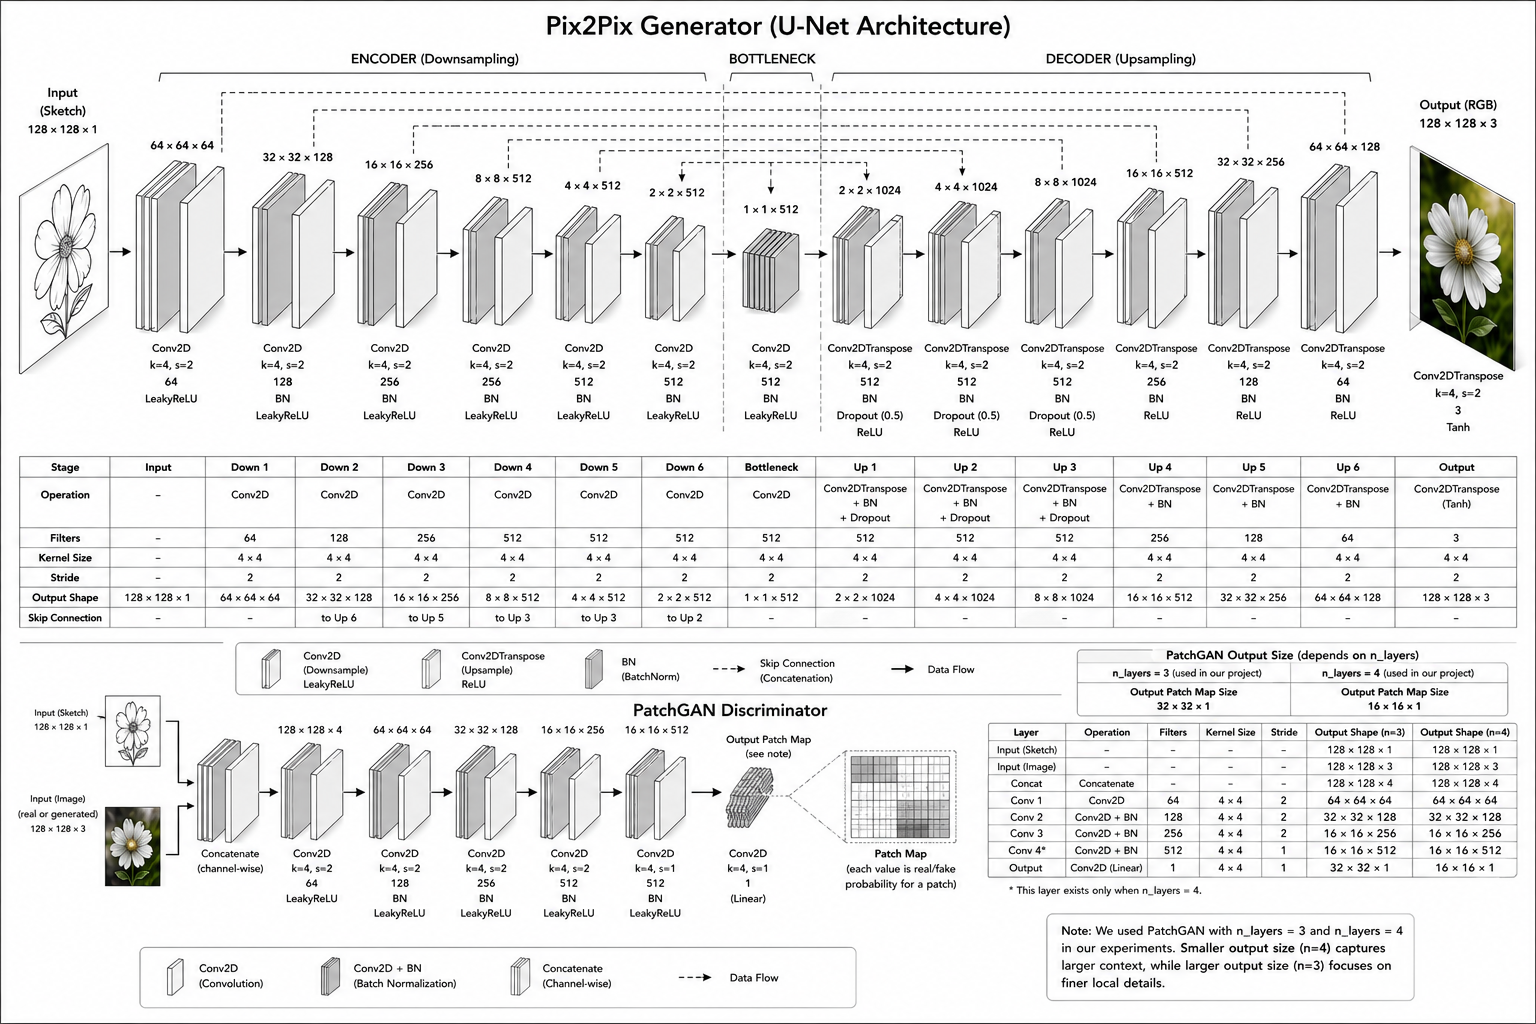

## Generator Building Blocks

We define:
- Downsample blocks (encoder)
- Upsample blocks (decoder)

These are used to construct the U-Net generator.

In [ ]:
def downsample(filters, size, apply_batchnorm=True, block_name="down"):
    initializer = tf.random_normal_initializer(0.0, 0.02)

    result = keras.Sequential(name=block_name)
    result.add(layers.Conv2D(
        filters, size, strides=2, padding="same",
        kernel_initializer=initializer,
        use_bias=False,
        name=f"{block_name}_conv"
    ))

    if apply_batchnorm:
        result.add(layers.BatchNormalization(name=f"{block_name}_bn"))

    result.add(layers.LeakyReLU(name=f"{block_name}_leaky_relu"))
    return result


def upsample(filters, size, apply_dropout=False, block_name="up"):
    initializer = tf.random_normal_initializer(0.0, 0.02)

    result = keras.Sequential(name=block_name)
    result.add(layers.Conv2DTranspose(
        filters, size, strides=2, padding="same",
        kernel_initializer=initializer,
        use_bias=False,
        name=f"{block_name}_conv_transpose"
    ))

    result.add(layers.BatchNormalization(name=f"{block_name}_bn"))

    if apply_dropout:
        result.add(layers.Dropout(0.5, name=f"{block_name}_dropout"))

    result.add(layers.ReLU(name=f"{block_name}_relu"))
    return result

## Generator (U-Net)

We use a U-Net architecture with skip connections.

Skip connections transfer spatial information from encoder to decoder, helping preserve structure from the input sketch.

This improves alignment between the sketch and the generated image.

In [ ]:
def build_unet_generator(img_size=128):
    inputs = layers.Input(
        shape=(img_size, img_size, 1),
        name="generator_input_sketch"
    )

    down_stack = [
        downsample(64, 4, apply_batchnorm=False, block_name="gen_down_1"),
        downsample(128, 4, block_name="gen_down_2"),
        downsample(256, 4, block_name="gen_down_3"),
        downsample(512, 4, block_name="gen_down_4"),
        downsample(512, 4, block_name="gen_down_5"),
        downsample(512, 4, block_name="gen_down_6"),
        downsample(512, 4, block_name="gen_bottleneck"),
    ]

    up_stack = [
        upsample(512, 4, apply_dropout=True, block_name="gen_up_1"),
        upsample(512, 4, apply_dropout=True, block_name="gen_up_2"),
        upsample(512, 4, apply_dropout=True, block_name="gen_up_3"),
        upsample(256, 4, block_name="gen_up_4"),
        upsample(128, 4, block_name="gen_up_5"),
        upsample(64, 4, block_name="gen_up_6"),
    ]

    initializer = tf.random_normal_initializer(0.0, 0.02)

    last = layers.Conv2DTranspose(
        3,
        4,
        strides=2,
        padding="same",
        kernel_initializer=initializer,
        activation="tanh",
        name="generator_output_rgb"
    )

    x = inputs
    skips = []

    for down in down_stack:
        x = down(x)
        skips.append(x)

    skips = reversed(skips[:-1])

    for idx, (up, skip) in enumerate(zip(up_stack, skips), start=1):
        x = up(x)
        x = layers.Concatenate(name=f"gen_skip_connection_{idx}")([x, skip])

    outputs = last(x)

    return keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="pix2pix_unet_generator"
    )

In [ ]:
generator = build_unet_generator(IMG_SIZE)
generator.summary()

### Generator Summary Discussion

The generator is deeper than the naive model and uses skip connections to preserve spatial details.

## Discriminator (PatchGAN)

The discriminator evaluates local image patches instead of the full image.

This encourages realistic textures and sharp details.

We compare two configurations:
- n_layers = 3 (smaller receptive field)
- n_layers = 4 (larger receptive field)

The receptive field controls how much of the image each decision considers:

- smaller -> focuses on local details  
- larger -> captures global structure

In [ ]:
def build_patch_discriminator(img_size=128, base_filters=64, n_layers=3, name="patchgan_discriminator"):
    initializer = tf.random_normal_initializer(0.0, 0.02)

    inp = layers.Input(
        shape=(img_size, img_size, 1),
        name="disc_input_sketch"
    )

    tar = layers.Input(
        shape=(img_size, img_size, 3),
        name="disc_input_target_or_generated"
    )

    x = layers.Concatenate(name="disc_concat_sketch_and_image")([inp, tar])

    filters = base_filters

    x = layers.Conv2D(
        filters,
        4,
        strides=2,
        padding="same",
        kernel_initializer=initializer,
        name="disc_conv_1"
    )(x)
    x = layers.LeakyReLU(name="disc_leaky_relu_1")(x)

    for i in range(1, n_layers):
        filters = min(base_filters * (2 ** i), 512)
        stride = 1 if i == n_layers - 1 else 2

        x = layers.Conv2D(
            filters,
            4,
            strides=stride,
            padding="same",
            kernel_initializer=initializer,
            use_bias=False,
            name=f"disc_conv_{i + 1}"
        )(x)

        x = layers.BatchNormalization(name=f"disc_batchnorm_{i + 1}")(x)
        x = layers.LeakyReLU(name=f"disc_leaky_relu_{i + 1}")(x)

    x = layers.Conv2D(
        1,
        4,
        strides=1,
        padding="same",
        kernel_initializer=initializer,
        name="disc_output_patch_map"
    )(x)

    return keras.Model(
        inputs=[inp, tar],
        outputs=x,
        name=name
    )

In [ ]:
discriminator_small = build_patch_discriminator(
    IMG_SIZE,
    n_layers=3,
    name="patchgan_discriminator_n3"
)

discriminator_large = build_patch_discriminator(
    IMG_SIZE,
    n_layers=4,
    name="patchgan_discriminator_n4"
)




In [ ]:
discriminator_small.summary()

In [ ]:
discriminator_large.summary()

### Discriminator Summary Discussion

The discriminator outputs a grid of decisions over local patches instead of a single score.

This enforces local realism and allows comparison between different receptive fields.

## Loss Functions

The generator loss combines:
- adversarial loss (realism)
- L1 loss (similarity to target)

Total loss = GAN loss + λ * L1 loss

We use λ = 100.

In [ ]:
loss_object = keras.losses.BinaryCrossentropy(from_logits=True)
LAMBDA = 100


def discriminator_loss(disc_real_output, disc_generated_output):
    real_loss = loss_object(tf.ones_like(disc_real_output), disc_real_output)
    generated_loss = loss_object(tf.zeros_like(disc_generated_output), disc_generated_output)
    total_disc_loss = real_loss + generated_loss
    return total_disc_loss


def generator_loss(disc_generated_output, gen_output, target, lambda_l1):
    gan_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)
    l1_loss = tf.reduce_mean(tf.abs(target - gen_output))
    total_gen_loss = gan_loss + lambda_l1 * l1_loss
    return total_gen_loss, gan_loss, l1_loss

## Training Process

For each batch:
1. Generator produces an image from the sketch  
2. Discriminator evaluates real and generated pairs  
3. Generator is updated using GAN + L1 loss  
4. Discriminator is updated to distinguish real from fake  

We track generator, discriminator, and validation losses, and save outputs during training.

In [ ]:
def fit_pix2pix(train_dataset, val_dataset, epochs, generator, discriminator, experiment_name, lambda_l1=100):
    patience = 8
    epochs_without_improvement = 0

    history = {
        "gen_total_loss": [],
        "gen_gan_loss": [],
        "gen_l1_loss": [],
        "disc_loss": [],
        "val_l1_loss": []
    }

    generator_optimizer = keras.optimizers.Adam(2e-4, beta_1=0.5)
    discriminator_optimizer = keras.optimizers.Adam(2e-4, beta_1=0.5)

    sample_sketches, sample_targets = next(iter(val_dataset))

    experiment_dir = PIX2PIX_DIR / experiment_name
    experiment_dir.mkdir(parents=True, exist_ok=True)

    best_generator_path = experiment_dir / "best_generator.keras"
    best_discriminator_path = experiment_dir / "best_discriminator.keras"
    last_generator_path = experiment_dir / "last_generator.keras"
    last_discriminator_path = experiment_dir / "last_discriminator.keras"
    history_csv_path = experiment_dir / "history.csv"
    metadata_path = METADATA_DIR / f"{experiment_name}.json"

    best_val_l1 = float("inf")
    best_epoch = -1

    @tf.function
    def train_step(input_image, target):
        with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
            gen_output = generator(input_image, training=True)

            disc_real_output = discriminator([input_image, target], training=True)
            disc_generated_output = discriminator([input_image, gen_output], training=True)

            total_gen_loss, gan_loss, l1_loss = generator_loss(
                disc_generated_output, gen_output, target, lambda_l1
            )
            disc_loss = discriminator_loss(disc_real_output, disc_generated_output)

        generator_gradients = gen_tape.gradient(total_gen_loss, generator.trainable_variables)
        discriminator_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

        generator_optimizer.apply_gradients(zip(generator_gradients, generator.trainable_variables))
        discriminator_optimizer.apply_gradients(zip(discriminator_gradients, discriminator.trainable_variables))

        return total_gen_loss, gan_loss, l1_loss, disc_loss

    for epoch in range(epochs):
        gen_total_list = []
        gen_gan_list = []
        gen_l1_list = []
        disc_list = []

        for input_image, target in train_dataset:
            gen_total_loss, gan_loss, l1_loss, disc_loss = train_step(input_image, target)

            gen_total_list.append(gen_total_loss.numpy())
            gen_gan_list.append(gan_loss.numpy())
            gen_l1_list.append(l1_loss.numpy())
            disc_list.append(disc_loss.numpy())

        history["gen_total_loss"].append(np.mean(gen_total_list))
        history["gen_gan_loss"].append(np.mean(gen_gan_list))
        history["gen_l1_loss"].append(np.mean(gen_l1_list))
        history["disc_loss"].append(np.mean(disc_list))

        # Validation
        val_l1_list = []
        for val_input, val_target in val_dataset:
            val_pred = generator(val_input, training=False)
            val_l1 = tf.reduce_mean(tf.abs(val_target - val_pred))
            val_l1_list.append(val_l1.numpy())

        current_val_l1 = float(np.mean(val_l1_list))
        history["val_l1_loss"].append(current_val_l1)

        # Best model check
        if current_val_l1 < best_val_l1:
            best_val_l1 = current_val_l1
            best_epoch = epoch + 1
            epochs_without_improvement = 0

            generator.save(best_generator_path)
            discriminator.save(best_discriminator_path)

            print(f"New best model saved at epoch {epoch + 1} with Val L1 = {best_val_l1:.4f}")
        else:
            epochs_without_improvement += 1

        # Logging
        print(
            f"Epoch {epoch + 1}/{epochs} - "
            f"Gen Total: {history['gen_total_loss'][-1]:.4f} | "
            f"Gen GAN: {history['gen_gan_loss'][-1]:.4f} | "
            f"Gen L1: {history['gen_l1_loss'][-1]:.4f} | "
            f"Val L1: {history['val_l1_loss'][-1]:.4f} | "
            f"Disc: {history['disc_loss'][-1]:.4f}"
        )

        # Visualization
        preds = generator(sample_sketches[:3], training=False).numpy()

        plt.figure(figsize=(12, 12))
        for i in range(3):
            plt.subplot(3, 3, 3 * i + 1)
            plt.imshow(denormalize(sample_sketches[i, :, :, 0]), cmap="gray")
            plt.title("Sketch")
            plt.axis("off")

            plt.subplot(3, 3, 3 * i + 2)
            plt.imshow(denormalize(preds[i]))
            plt.title(f"Generated - Epoch {epoch + 1}")
            plt.axis("off")

            plt.subplot(3, 3, 3 * i + 3)
            plt.imshow(denormalize(sample_targets[i]))
            plt.title("Target")
            plt.axis("off")

        plt.tight_layout()
        plt.savefig(experiment_dir / f"epoch_{epoch + 1:03d}.png")
        plt.show()

        #Early Stopping
        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

    # Save last models
    generator.save(last_generator_path)
    discriminator.save(last_discriminator_path)

    pd.DataFrame(history).to_csv(history_csv_path, index=False)

    save_experiment_metadata(
        metadata_path,
        {
            "experiment_name": experiment_name,
            "model_type": "pix2pix",
            "lambda_l1": lambda_l1,
            "generator_optimizer": "Adam(beta_1=0.5, lr=2e-4)",
            "discriminator_optimizer": "Adam(beta_1=0.5, lr=2e-4)",
            "epochs_requested": epochs,
            "best_val_l1": best_val_l1,
            "best_epoch": best_epoch,
            "best_generator_path": str(best_generator_path),
            "best_discriminator_path": str(best_discriminator_path),
            "last_generator_path": str(last_generator_path),
            "last_discriminator_path": str(last_discriminator_path),
            "history_csv_path": str(history_csv_path)
        }
    )

    return history

# Pix2Pix Experiments

We compare two PatchGAN configurations:

- n_layers = 3 (smaller receptive field)
- n_layers = 4 (larger receptive field)

Goal:
To evaluate the effect of receptive field on image quality and training behavior.

## Experiment: Small PatchGAN (n_layers = 3)

Configuration:
- Generator: U-Net
- Discriminator: PatchGAN (n_layers = 3)
- Loss: GAN + L1 (λ = 100)

Focus:
Local texture and fine details

In [ ]:
generator_small = build_unet_generator(IMG_SIZE)
discriminator_small = build_patch_discriminator(IMG_SIZE, n_layers=3)

In [ ]:
history_pix2pix_small = fit_pix2pix(
    train_ds,
    val_ds,
    epochs=50,
    generator=generator_small,
    discriminator=discriminator_small,
    experiment_name="pix2pix_patch_small"
)

In [ ]:
print("Best small PatchGAN validation L1:", min(history_pix2pix_small["val_l1_loss"]))
print("Final generator loss:", history_pix2pix_small["gen_total_loss"][-1])
print("Final discriminator loss:", history_pix2pix_small["disc_loss"][-1])

In [ ]:
pd.DataFrame(history_pix2pix_small).to_csv(OUTPUT_DIR / "pix2pix_small_history.csv", index=False)

## Experiment: Large PatchGAN (n_layers = 4)

Configuration:
- Generator: U-Net
- Discriminator: PatchGAN (n_layers = 4)
- Loss: GAN + L1 (λ = 100)

Focus:
Global structure and consistency

In [ ]:
generator_large = build_unet_generator(IMG_SIZE)
discriminator_large = build_patch_discriminator(IMG_SIZE, n_layers=4)

In [ ]:
history_pix2pix_large = fit_pix2pix(
    train_ds,
    val_ds,
    epochs=50,
    generator=generator_large,
    discriminator=discriminator_large,
    experiment_name="pix2pix_patch_large"
)

In [ ]:
print("Best large PatchGAN validation L1:", min(history_pix2pix_large["val_l1_loss"]))
print("Final large PatchGAN generator loss:", history_pix2pix_large["gen_total_loss"][-1])
print("Final large PatchGAN discriminator loss:", history_pix2pix_large["disc_loss"][-1])

In [ ]:
pd.DataFrame(history_pix2pix_large).to_csv(OUTPUT_DIR / "pix2pix_large_history.csv", index=False)

## Convergence Comparison

We compare generator, discriminator, and validation losses between the two configurations.

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history_pix2pix_small["gen_total_loss"], label="Generator Loss - Small PatchGAN")
plt.plot(history_pix2pix_large["gen_total_loss"], label="Generator Loss - Large PatchGAN")
plt.title("Pix2Pix Generator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history_pix2pix_small["disc_loss"], label="Discriminator Loss - Small PatchGAN")
plt.plot(history_pix2pix_large["disc_loss"], label="Discriminator Loss - Large PatchGAN")
plt.title("Pix2Pix Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history_pix2pix_small["val_l1_loss"], label="Validation L1 - Small PatchGAN")
plt.plot(history_pix2pix_large["val_l1_loss"], label="Validation L1 - Large PatchGAN")
plt.title("Pix2Pix Validation L1 Loss")
plt.xlabel("Epoch")
plt.ylabel("L1 Loss")
plt.legend()
plt.grid(True)
plt.show()

# Visual Comparison

We compare outputs from:
- Naive model
- Pix2Pix (n=3)
- Pix2Pix (n=4)
- Ground truth

In [ ]:
best_naive = keras.models.load_model(NAIVE_BEST_MODEL_PATH)
best_pix2pix_small = keras.models.load_model(PIX2PIX_DIR / "pix2pix_patch_small" / "best_generator.keras")
best_pix2pix_large = keras.models.load_model(PIX2PIX_DIR / "pix2pix_patch_large" / "best_generator.keras")

sketches, targets = next(iter(test_ds))

naive_preds = best_naive.predict(sketches[:3], verbose=0)
pix2pix_small_preds = best_pix2pix_small.predict(sketches[:3], verbose=0)
pix2pix_large_preds = best_pix2pix_large.predict(sketches[:3], verbose=0)

plt.figure(figsize=(16, 12))
for i in range(3):
    plt.subplot(3, 5, 5 * i + 1)
    plt.imshow(denormalize(sketches[i, :, :, 0]), cmap="gray")
    plt.title("Sketch")
    plt.axis("off")

    plt.subplot(3, 5, 5 * i + 2)
    plt.imshow(denormalize(naive_preds[i]))
    plt.title("Naive")
    plt.axis("off")

    plt.subplot(3, 5, 5 * i + 3)
    plt.imshow(denormalize(pix2pix_small_preds[i]))
    plt.title("Pix2Pix Small")
    plt.axis("off")

    plt.subplot(3, 5, 5 * i + 4)
    plt.imshow(denormalize(pix2pix_large_preds[i]))
    plt.title("Pix2Pix Large")
    plt.axis("off")

    plt.subplot(3, 5, 5 * i + 5)
    plt.imshow(denormalize(targets[i]))
    plt.title("Target")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Discussion

Pix2Pix improves image quality compared to the naive baseline.

- Adversarial loss improves realism and sharpness  
- L1 loss preserves global structure  

Effect of receptive field:
- n=3 -> sharper local details  
- n=4 -> better global consistency  

Pix2Pix provides a better balance between realism and structure.



---



---



## Final Model Selection

Although the n=4 model achieves slightly lower validation L1 loss, the n=3 model produces sharper and more detailed images.

The smaller PatchGAN focuses on local textures, which leads to more realistic and visually appealing results.

Therefore, the Pix2Pix model with n_layers = 3 is selected as the final model.

## Experiment Summary Table

To summarize the project clearly, we collect the main experiments and their key validation results in a single table.

This helps us compare the methods in a more organized way and supports the final model selection.

In [ ]:
experiment_summary = pd.DataFrame([
    {
        "Method": "Naive",
        "Loss": "MSE",
        "Best Val": min(history_naive.history["val_loss"]),
    },
    {
        "Method": "Pix2Pix (n=3)",
        "Loss": "GAN + L1",
        "Best Val": min(history_pix2pix_small["val_l1_loss"]),
    },
    {
        "Method": "Pix2Pix (n=4)",
        "Loss": "GAN + L1",
        "Best Val": min(history_pix2pix_large["val_l1_loss"]),
    }
])

display(experiment_summary)

Note:
The loss values are not directly comparable between models, since the naive model uses MSE while Pix2Pix uses L1 within a GAN framework.

Therefore, visual quality is the main criterion for model selection.